# Problem B: Solve Pressure Field in 2D Heterogeneous Porous Media

Consider a square domain $\Omega = [0,1]^2$ representing a heterogeneous porous medium composed of two distinct material phases with significantly different permeabilities, for instance, high-permeability sandstone inclusions embedded in a low-permeability mudstone matrix. Such heterogeneous structures arise frequently in subsurface flow engineering, including groundwater modeling, hydrocarbon reservoir simulation, and fuel cell design. Near the interface between the two phases, the pressure gradient exhibits sharp transitions, making this a classical benchmark for testing the robustness of PDE solvers under non-smooth coefficients.

The permeability field $\mu(x)$ is defined as:

$$
\mu(x) =
\begin{cases}
\mu_1 = 10, & x \in \Omega_1 \quad \text{(high-permeability phase, e.g., sandstone)} \\
\mu_2 = 2,  & x \in \Omega_2 \quad \text{(low-permeability phase, e.g., mudstone)}
\end{cases}
$$

The specific two-phase microstructure (i.e., the geometric distribution of $\Omega_1$ and $\Omega_2$) is provided in the dataset. The pressure field $u(x)$ satisfies the following Darcy flow equation:

$$
-\nabla \cdot \left(\mu(x)\,\nabla u\right) = f, \quad x \in \Omega \tag{1}
$$

where
- $u(x):$ pressure field in the porous medium
- $\mu(x):$ spatially varying permeability field
- $f = 0:$ source term (no internal source/sink)
- $\Omega = [0,1]^2:$ square computational domain

The boundary conditions are prescribed as follows, driving fluid flow from the high-pressure inlet on the left to the low-pressure outlet on the right:

$$
g_D(x) =
\begin{cases}
1, & x_1 = 0 \quad \text{(left boundary, high-pressure inlet)} \\
0, & x_1 = 1 \quad \text{(right boundary, low-pressure outlet)} \\
\text{linear interpolation}, & x_2 = 0 \text{ or } 1 \quad \text{(top and bottom boundaries)}
\end{cases}
$$

## Task: Solve the pressure field $u(x)$

In this task, the permeability field $\mu(x)$ is provided as a $128 \times 128$ pixel matrix — that is, the domain is subdivided into $128 \times 128$ cells, each with a constant permeability value. Using this permeability field, apply a suitable method introduced in the lecture to solve for the pressure field $u(x)$ in the heterogeneous porous medium.

### The Goals
- Please select a suitable deep learning method for solving this forward problem to compute the pressure field $u(x)$, and explain the reason for using it.
- Report your setups for the implementation, such as network structure, activation function, optimizer (with learning rate), epoch (with batch size), loss weights, and other tricks that are used for improvement.
- Compute the $L^2$ relative error (on the testing dataset) at each training epoch and plot the `Error vs. epoch` curve (and report the final error). The $L^2$ relative error between the prediction $u_\text{pred}$ and the reference $u_\text{true}$ is defined as follows:

$$
\text{error} = \sqrt{\frac{\sum_i^n \left| u_\text{pred}(x_i) - u_\text{true}(x_i) \right|^2}{\sum_i^n \left| u_\text{true}(x_i) \right|^2}}
$$

- Plot the predicted solution (and the ground truth reference) and the pointwise absolute error using separate figures with `matplotlib`.

### Dataset

The permeability field and the reference solution are provided in the dataset `ProblemB_dataset.h5`:

- `mu_field`: the permeability field $\mu(x)$, represented as a $128 \times 128$ pixel matrix, where each cell has a constant permeability value (available for training)
- `x_test`: the locations where the reference solution is evaluated (Used for computing error and should **not** be used for training)
- `u_test`: the reference pressure field values (used for computing error and should **not** be used for training)
- Link to dataset: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

x_test: torch.Size([16384, 2]) u_test: torch.Size([128, 128]) mu_field: torch.Size([128, 128])


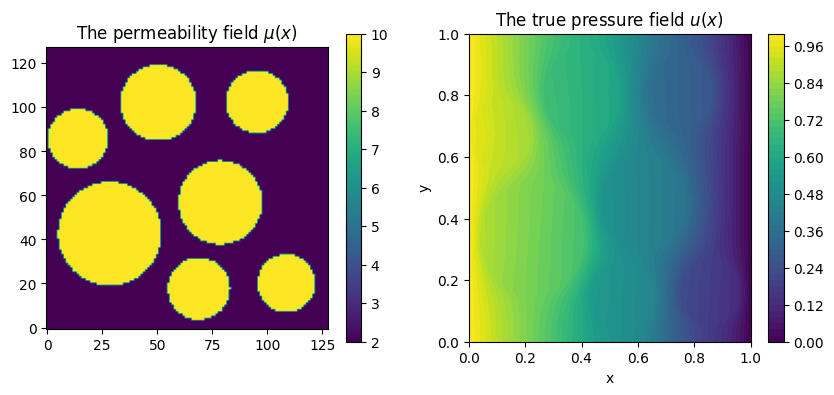

In [1]:
import numpy as np
import torch
import h5py
import matplotlib.pyplot as  plt

# ################################# The testing dataset
with h5py.File('ProblemB_dataset.h5', 'r') as f:
    x_test = torch.tensor(np.array(f['x_test']), dtype=torch.float32)
    u_test = torch.tensor(np.array(f['u_test']), dtype=torch.float32) # Should not be used for training !!!
    mu_field = torch.tensor(np.array(f['mu_field']), dtype=torch.float32)
print('x_test:', x_test.shape, 'u_test:', u_test.shape, 'mu_field:', mu_field.shape)
#
def fun_mu(x, mu=mu_field, resolution=128):
    '''The material property field (get values of material field on any given position x)
    Input:
        x: size(N, 2)
    '''
    mu = mu.reshape(1,-1).to(x)
    delta = 1./(resolution-1)
    #
    x_loc = torch.floor(x[...,0] / delta + 0.5).int()
    y_loc = torch.floor(x[...,1] / delta + 0.5).int()
    loc = y_loc * resolution + x_loc
    #
    mu_new = mu[torch.arange(mu.shape[0]).unsqueeze(1), loc]
    
    return mu_new.T

mu = fun_mu(x_test)

# ##################################
fig, axes = plt.subplots(1, 2, figsize=(10,4))
#
cntr = axes[0].imshow(mu.reshape(128,128), origin='lower')
axes[0].set_title(r'The permeability field $\mu(x)$')
plt.colorbar(cntr)
#
cntr = axes[1].contourf(x_test[:,0].reshape(128, 128), x_test[:,1].reshape(128, 128), u_test, levels=50)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title(r'The true pressure field $u(x)$')
plt.colorbar(cntr)
plt.show()

Using device: cuda
x_test: torch.Size([16384, 2])
u_test: torch.Size([16384, 1])
u_test_grid: torch.Size([128, 128])
mu_field: torch.Size([128, 128])


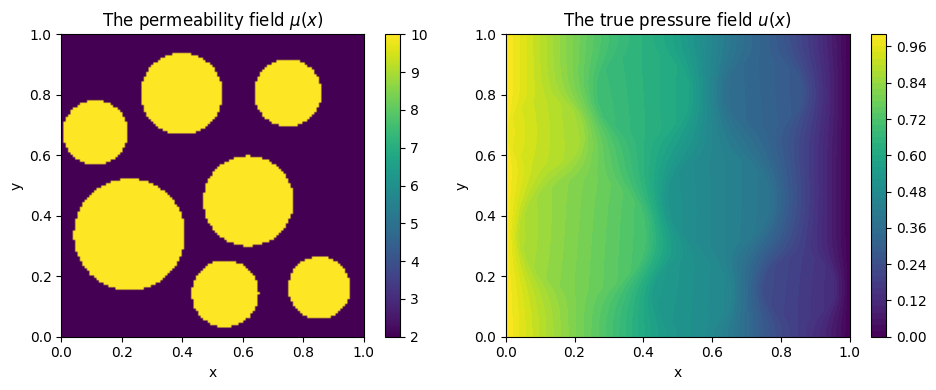

x_train_all: torch.Size([65536, 2])
mu_train_all: torch.Size([65536, 1])
xy_mu_train_all torch.Size([65536, 3])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   FourierFeatures-1                   [-1, 14]               0
            Linear-2                  [-1, 128]           1,920
              Tanh-3                  [-1, 128]               0
            Linear-4                  [-1, 128]          16,512
              Tanh-5                  [-1, 128]               0
            Linear-6                  [-1, 128]          16,512
              Tanh-7                  [-1, 128]               0
            Linear-8                  [-1, 128]          16,512
              Tanh-9                  [-1, 128]               0
           Linear-10                    [-1, 1]             129
              MLP-11                    [-1, 1]               0
Total params: 51,585
Trainable params: 51,585
Non-train

 10%|█         | 205/2000 [00:04<00:38, 46.23it/s]

Epoch:200, loss:1.793347e+00, energy:1.793347e+00, reg:0.000000e+00, error:3.156313e-02, best_error:3.094765e-02, lr:2.000e-04


 20%|██        | 405/2000 [00:08<00:34, 46.16it/s]

Epoch:400, loss:1.760174e+00, energy:1.760174e+00, reg:0.000000e+00, error:3.078491e-02, best_error:3.034824e-02, lr:2.000e-04


...

Epoch:1600, loss:1.727606e+00, energy:1.727606e+00, reg:0.000000e+00, error:3.099541e-02, best_error:3.028553e-02, lr:2.500e-05


 90%|█████████ | 1805/2000 [00:38<00:04, 44.69it/s]

Epoch:1800, loss:1.726195e+00, energy:1.726195e+00, reg:0.000000e+00, error:3.089337e-02, best_error:3.028553e-02, lr:2.500e-05


100%|██████████| 2000/2000 [00:42<00:00, 46.73it/s]


Epoch:2000, loss:1.724740e+00, energy:1.724740e+00, reg:0.000000e+00, error:3.100732e-02, best_error:3.028553e-02, lr:1.250e-05
Best L2 relative error: 0.030285527929663658
Final L2 relative error: 0.030285527929663658


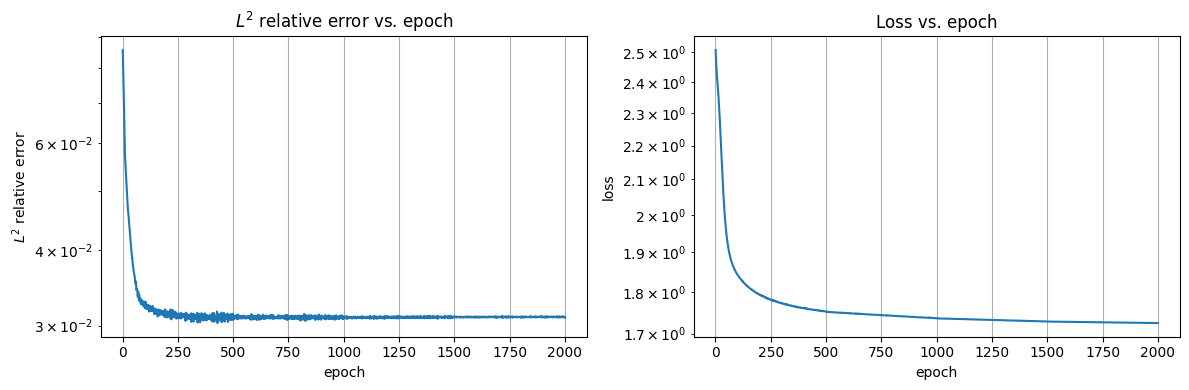

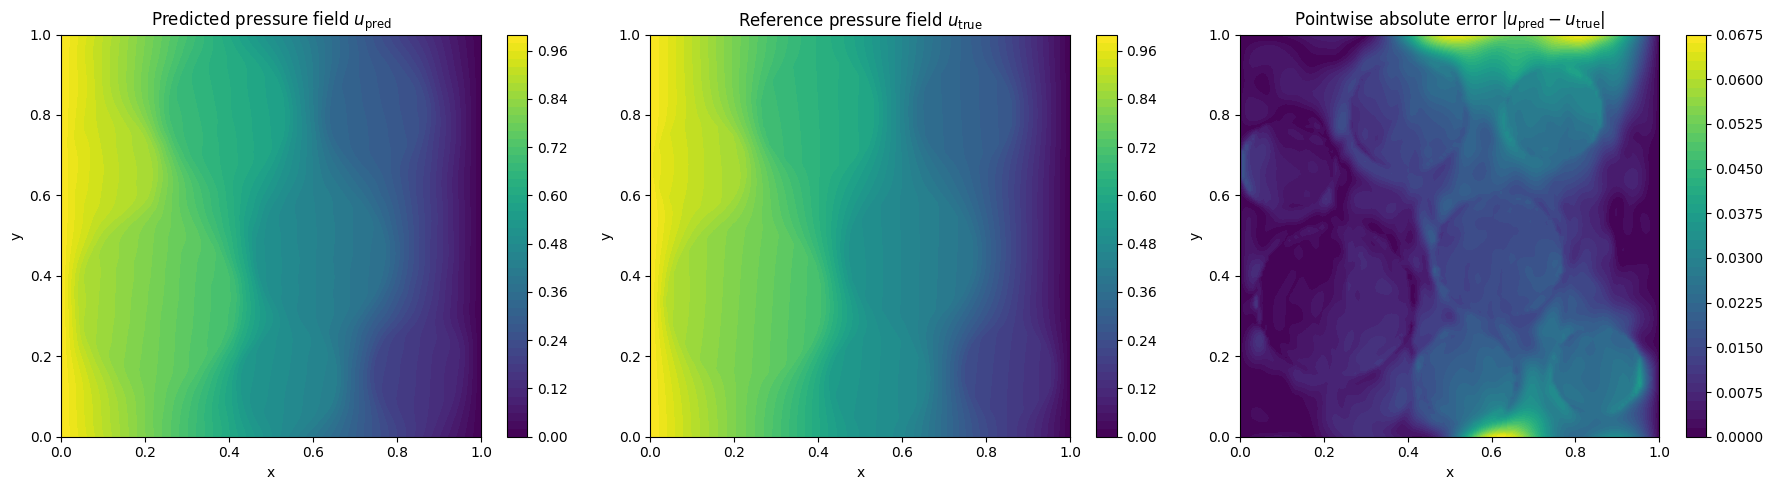

In [9]:
#############################################################
# Problem B: Solve Pressure Field in 2D Heterogeneous Porous Media
# Method: Deep Ritz Method
#############################################################

#############################################################
# Step 0: Import packages and global settings
#############################################################
import os
import time
import h5py
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.autograd import grad
from tqdm import trange
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader



device = "cuda" 
dataType = torch.float32

np.random.seed(1234)
torch.manual_seed(1234)
torch.cuda.manual_seed_all(1234)

print("Using device:", device)


#############################################################
# Step 1: Load dataset
#############################################################

with h5py.File("ProblemB_dataset.h5", "r") as f:
    x_test = torch.tensor(np.array(f["x_test"]), dtype=dataType)
    u_test = torch.tensor(np.array(f["u_test"]), dtype=dataType)
    mu_field = torch.tensor(np.array(f["mu_field"]), dtype=dataType)

x_test_cpu = x_test.reshape(-1, 2)
u_test_grid = u_test.reshape(128, 128)
u_test_cpu = u_test.reshape(-1, 1)
mu_field_cpu = mu_field.reshape(128, 128)

x_test = x_test_cpu.to(device)
u_test = u_test_cpu.to(device)
mu_field = mu_field_cpu.to(device)

print("x_test:", x_test.shape)
print("u_test:", u_test.shape)
print("u_test_grid:", u_test_grid.shape)
print("mu_field:", mu_field.shape)


#############################################################
# Step 2: Teacher-style permeability lookup function
#############################################################

def fun_mu(x, mu=mu_field, resolution=128):
    """
    Input:
        x: torch tensor, shape (N,2), coordinates in [0,1]^2

    Return:
        mu_new: torch tensor, shape (N,1)

    Function:
        GPU lookup for permeability field.
    """

    x_detach = x.detach()

    x_loc = torch.floor(x_detach[:, 0:1] * resolution).long()
    y_loc = torch.floor(x_detach[:, 1:2] * resolution).long()
    x_loc = torch.clamp(x_loc, 0, resolution - 1)
    y_loc = torch.clamp(y_loc, 0, resolution - 1)

    mu_new = mu[y_loc.squeeze(1), x_loc.squeeze(1)].reshape(-1, 1)

    return mu_new


#############################################################
# Step 3: Plot permeability field and reference pressure field
#############################################################

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cntr0 = axes[0].imshow(fun_mu(x_test).reshape(128, 128).cpu(), origin="lower", extent=[0, 1, 0, 1])
axes[0].set_title(r"The permeability field $\mu(x)$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(cntr0, ax=axes[0])

cntr1 = axes[1].contourf(x_test[:, 0].reshape(128, 128).cpu(), x_test[:, 1].reshape(128, 128).cpu(), u_test.reshape(128, 128).cpu(), levels=50)
axes[1].set_title(r"The true pressure field $u(x)$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(cntr1, ax=axes[1])

plt.tight_layout()
plt.show()


#############################################################
# Step 4: Generate training integration points from mu_field
# Use random points on omega (Monte Carlo approximation)
#############################################################

lb = torch.tensor([0.0, 0.0], dtype=dataType, device=device)
ub = torch.tensor([1.0, 1.0], dtype=dataType, device=device)

n_int = 65536

with torch.no_grad():    
    xy_train_all = lb + (ub - lb) * torch.rand(n_int, 2, dtype=dataType, device=device)
    
    mu_train_all = fun_mu(xy_train_all)
    
    xy_mu_train_all = torch.cat([xy_train_all, mu_train_all], dim=1)

print("x_train_all:", xy_train_all.shape)
print("mu_train_all:", mu_train_all.shape)
print("xy_mu_train_all", xy_mu_train_all.shape)


#############################################################
# Step 5: Define neural network
#############################################################

class FourierFeatures(nn.Module):
    """
    Mild Fourier feature embedding.

    Input:
        x: torch tensor, shape (N,2)

    Return:
        features: torch tensor, shape (N, 2 + 4*num_freq)
    """

    def __init__(self, frequencies):
        super(FourierFeatures, self).__init__()
        self.frequencies = frequencies

    def forward(self, x):
        features = [x]

        for freq in self.frequencies:
            features.append(torch.sin(2.0 * torch.pi * freq * x))
            features.append(torch.cos(2.0 * torch.pi * freq * x))

        return torch.cat(features, dim=1)


class MLP(nn.Module):
    """
    MLP for approximating the correction term N_theta(x,y).
    """

    def __init__(self, layers_list: list, dtype=None):
        super(MLP, self).__init__()

        self.activation = nn.Tanh()

        net = []
        self.hidden_in = layers_list[0]

        for hidden in layers_list[1:]:
            net.append(nn.Linear(self.hidden_in, hidden, dtype=dtype))
            self.hidden_in = hidden

        self.net = nn.Sequential(*net)

        self.initialize_weights()

    def initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        for layer in self.net[:-1]:
            x = layer(x)
            x = self.activation(x)

        x = self.net[-1](x)

        return x


class PressureModel(nn.Module):
    """
    Pressure model with hard Dirichlet boundary condition.

    Boundary:
        u(0,y) = 1
        u(1,y) = 0
        u(x,0) = 1 - x
        u(x,1) = 1 - x

    Construction:
        u_theta(x,y)
        =
        1 - x + 0.3*x(1-x)y(1-y)N_theta(x,y)
    """

    def __init__(self, width=128, depth=4, dtype=None):
        super(PressureModel, self).__init__()

        self.embedding = FourierFeatures(frequencies=[1, 2, 4])

        input_dim = 2 + 2 * 2 * 3

        layers = [input_dim]
        for _ in range(depth):
            layers.append(width)
        layers.append(1)

        self.net = MLP(layers, dtype=dtype)

    def forward(self, xy):
        x = xy[:, 0:1]
        y = xy[:, 1:2]

        features = self.embedding(xy)

        raw = self.net(features)

        u = 1.0-x+0.3*x*(1.0-x)*y*(1.0-y)*raw ### Mollifier

        return u


model_u = PressureModel(width=128, depth=4, dtype=dataType).to(device)
summary(model_u, input_size=(2,), device=device)


#############################################################
# Step 6: Define Deep Ritz loss class
#############################################################

class LossClass(object):
    """
    Deep Ritz loss for:
        - div(mu grad u) = 0
    Energy functional:
        J(u) = integral 1/2 mu |grad u|^2 dxdy
    Since f = 0, there is no source term.
    """

    def __init__(self, u_model):
        self.device = device
        self.u_model = u_model

    def loss_energy(self, x_batch, mu_batch):
        """
        Input:
            x_batch: torch tensor, shape (batch_size,2)
            mu_batch: torch tensor, shape (batch_size,1)
        Return:
            loss: total loss
            energy: Deep Ritz energy
            correction_reg: regularization loss
        Function:
            Approximate:

                integral 1/2 mu |grad u|^2 dxdy
        Add a small regularization to avoid nonphysical high-frequency banding.
        """

        x = x_batch.detach().clone().requires_grad_(True)
        mu = mu_batch.to(x)
        u = self.u_model(x)

        du = grad(inputs=x, outputs=u, grad_outputs=torch.ones_like(u), create_graph=True)[0]

        grad_norm_sq = torch.sum(du ** 2, dim=1, keepdim=True)

        energy = torch.mean(0.5 * mu * grad_norm_sq)

        #baseline = 1.0 - x[:, 0:1]
        #correction_reg = torch.mean((u - baseline) ** 2)

        loss = energy #+ 1e-4 * correction_reg

        return loss, energy, #correction_reg

    def get_error(self, x_test, u_test):
        """
        Input:
            x_test: torch tensor, shape (N_test,2)
            u_test: torch tensor, shape (N_test,1)
        Return:
            relative L2 error
        """

        x_test = x_test.to(self.device)
        u_test = u_test.to(self.device)
        u_pred = self.u_model(x_test)
        error = torch.sqrt(torch.sum((u_pred - u_test) ** 2)/torch.sum(u_test ** 2))

        return error


#############################################################
# Step 7: Training setup
#############################################################

epochs = 2000
batch_size = 16384
lr = 2e-4
weight_decay = 1e-6

optimizer = torch.optim.Adam(params=model_u.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)
lossClass = LossClass(model_u)

error_list = []
loss_list = []
energy_list = []
reg_list = []

best_error = float("inf")
best_state = None

#############################################################
# Step 8: Training process
#############################################################

n_total = xy_mu_train_all.shape[0]
n_batches = n_total // batch_size

for epoch in trange(epochs):

    perm = torch.randperm(n_total, device=device)

    epoch_loss = 0.0
    epoch_energy = 0.0
    epoch_reg = 0.0

    for b in range(n_batches):
        idx = perm[b * batch_size : (b + 1) * batch_size]
        xy_batch = xy_mu_train_all[idx]
        x_batch = xy_batch[:, 0:2]
        mu_batch = xy_batch[:, 2:3]

        #loss_train, loss_energy, loss_reg = lossClass.loss_energy(x_batch, mu_batch)
        loss_train, loss_energy = lossClass.loss_energy(x_batch, mu_batch)

        optimizer.zero_grad(set_to_none=True)
        loss_train.backward()

        torch.nn.utils.clip_grad_norm_(model_u.parameters(), max_norm=5.0)

        optimizer.step()

        epoch_loss += loss_train.item()
        epoch_energy += loss_energy.item()
        #epoch_reg += loss_reg.item()

    scheduler.step()

    epoch_loss /= n_batches
    epoch_energy /= n_batches
    epoch_reg /= n_batches

    loss_list.append(epoch_loss)
    energy_list.append(epoch_energy)
    reg_list.append(epoch_reg)

    with torch.no_grad():
        error = lossClass.get_error(x_test, u_test)
        error_value = error.item()
        error_list.append(error_value)

        if error_value < best_error:
            best_error = error_value
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model_u.state_dict().items()
            }

    if (epoch + 1) % 200 == 0:
        print(
            f"Epoch:{epoch+1}, "
            f"loss:{epoch_loss:.6e}, "
            f"energy:{epoch_energy:.6e}, "
            f"reg:{epoch_reg:.6e}, "
            f"error:{error_value:.6e}, "
            f"best_error:{best_error:.6e}, "
            f"lr:{optimizer.param_groups[0]['lr']:.3e}"
        )

#############################################################
# Step 9: Load the best model
#############################################################

if best_state is not None:
    model_u.load_state_dict(
        {
            key: value.to(device)
            for key, value in best_state.items()
        }
    )

print("Best L2 relative error:", best_error)


#############################################################
# Step 10: Prediction on testing dataset
#############################################################

model_u.eval()

with torch.no_grad():
    u_pred = model_u(x_test).detach().cpu()

u_test_cpu = u_test.detach().cpu()
final_error = torch.sqrt(torch.sum((u_pred - u_test_cpu) ** 2)/torch.sum(u_test_cpu ** 2))

print("Final L2 relative error:", final_error.item())

#############################################################
# Step 11: Plot error vs epoch, loss vs epoch
#############################################################

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(np.arange(1, len(error_list) + 1), error_list)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel(r"$L^2$ relative error")
axes[0].set_title(r"$L^2$ relative error vs. epoch")
axes[0].grid(True)

axes[1].semilogy(np.arange(1, len(loss_list) + 1), loss_list)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("Loss vs. epoch")
axes[1].grid(True)

plt.tight_layout()
plt.show()


#############################################################
# Step 12: Plot predicted solution, reference solution, and error together
#############################################################

u_pred_grid = u_pred.reshape(128, 128)
u_true_grid = u_test_cpu.reshape(128, 128)
abs_error_grid = torch.abs(u_pred_grid - u_true_grid)

X_plot = x_test[:, 0].reshape(128, 128).cpu()
Y_plot = x_test[:, 1].reshape(128, 128).cpu()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cntr0 = axes[0].contourf(X_plot, Y_plot, u_pred_grid, levels=50)
axes[0].set_title(r"Predicted pressure field $u_{\mathrm{pred}}$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(cntr0, ax=axes[0])

cntr1 = axes[1].contourf(X_plot, Y_plot, u_true_grid, levels=50)
axes[1].set_title(r"Reference pressure field $u_{\mathrm{true}}$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(cntr1, ax=axes[1])

cntr2 = axes[2].contourf(X_plot, Y_plot, abs_error_grid, levels=50)
axes[2].set_title(r"Pointwise absolute error $|u_{\mathrm{pred}}-u_{\mathrm{true}}|$")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(cntr2, ax=axes[2])

plt.tight_layout()
plt.show()